<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch13_Explainable_Outlier_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13 — Explainable Outlier Detection

An outlier detector that returns only a score is only half useful. If a model flags row 2407 as anomalous with score $-0.74$, an auditor, fraud investigator, or data scientist still has to answer the next question: **why?** Without that answer, the score is a lead with no evidence attached, and the downstream work — investigation, mitigation, model tuning, regulatory justification — is manual and error-prone.

This chapter introduces **eXplainable AI (XAI)** for outlier detection. We cover two philosophies:

- **Interpretability** — use a detector whose mechanism is directly readable by a human (histogram tests, rules, shallow trees).
- **Explainability** — use a black-box detector and apply *post hoc* tools (SHAP, proxy models, ALE plots, counterfactuals) to reconstruct an approximate story about why each record scored as it did.

Along the way we will meet four general-purpose XAI techniques — feature importances, proxy models, plotting, and counterfactuals — and three interpretable detectors designed specifically for outlier detection: **BHAD**, **CountsOutlierDetector**, and **DataConsistencyChecker**.

---

## Notebook roadmap

| Section | Topic | Technique |
|---|---|---|
| §13.1 | What XAI is, and why outlier detection needs it | Concepts |
| §13.2.1 | **Feature importances** | SHAP TreeExplainer |
| §13.2.2 | **Proxy models** | Decision trees, rule sets |
| §13.2.3 | **Plotting** | ALE (Accumulated Local Effects) |
| §13.2.4 | **Counterfactuals** | Minimum-change perturbations |
| §13.3.1 | Outlier detection on sets of 2D subspaces | Ensemble of 2-feature detectors |
| §13.3.2 | **BHAD** | Bayesian histogram detector |
| §13.3.3 | **CountsOutlierDetector** | Multi-dim bin counting |
| §13.3.4 | **DataConsistencyChecker** | Per-test anomaly voting |

---

### Environment note

The book uses the **abalone** dataset fetched from OpenML. This notebook is built in an environment without internet access, so we generate a **synthetic abalone dataset calibrated against the UCI marginals** (means, sds, ranges, sex-class proportions, and the characteristic length/diameter ≈ 1.22 ratio). The explanations, plots, and detector behaviors all qualitatively reproduce the book's findings. **Appendix A.1** contains the drop-in cell to fetch the real dataset on Colab.


## 13.1  Introducing XAI

### Why do outlier detectors need explaining?

The purposes we set for outlier detection — fraud triage, scientific discovery, data-quality review, real-time monitoring — all have the same downstream shape: **something is flagged, a human decides what to do about it**. That decision loop is fundamentally different depending on whether the flag comes with an explanation.

- **With an explanation**: "flagged because the Height value is 1.13, which exceeds the 99th percentile by a factor of ~5 and is inconsistent with the Length of 0.455." → investigator checks the shell, confirms measurement error or genuine anomaly, done in seconds.
- **Without one**: "flagged, score $-0.74$." → investigator opens the row, scans 8 columns, compares against dataset-wide stats manually, and tries to reverse-engineer the detector.

The cost of *reverse-engineering the detector on every flag* is the core motivator for XAI in outlier detection. When the flagged record triggers a real-world action (card frozen, machine halted, network access revoked), that cost is measured in minutes of customer impact.

### 13.1.1  Interpretability vs. explainability

These two words are often used interchangeably in casual conversation; in XAI they name two *different strategies*.

- **Interpretability** — pick a detector whose mechanism is inherently readable. Univariate tests (IQR, MAD), histogram methods (HBOS, ECOD), frequent-pattern detectors (FPOF), association rules, and Real-vs-Fake detectors with a shallow-tree classifier all belong here. You don't need a second system to understand them.
- **Explainability** — use a black-box detector (Isolation Forest, kNN, LOF, COF, SOD, PCA, One-Class SVM, …) and build a **post hoc** layer on top. This is where SHAP, proxy models, ALE plots, and counterfactuals live.

When interpretable detectors give you the accuracy you need, they are the preferred path. When they don't, explainability tools help you recover some of what you lost.

### 13.1.2  Global vs. local explanations

Inside either strategy, two scopes matter:

- A **global explanation** describes the detector as a whole: which features it emphasizes, what kinds of outliers it catches, how its score distributes.
- A **local explanation** describes *why this one row scored the way it did*.

You typically want both. Global explanations support model assessment, debugging, and ensemble design. Local explanations drive the per-row investigator workflow. We will see both at every step.

> 📐 **A useful mental model.** Global explanation = portrait of the detector.  Local explanation = zoom into one pixel. Good XAI pipelines produce both, from the same underlying machinery.


## Setup — the abalone dataset and an Isolation Forest

We'll follow the book's running example: fit an Isolation Forest on abalone, then spend the rest of the chapter trying to explain what it learned.

The abalone dataset has eight features: one categorical (**Sex** — M / F / I for Male / Female / Infant) and seven physical measurements (Length, Diameter, Height, Whole/Shucked/Viscera/Shell weights). All measurements are on correlated scales — a longer abalone is also wider and heavier — so the IF's notion of "outlier" here is really about records that break those joint regularities.


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.datasets import fetch_openml # Added this import

# Removed: from abalone_synth import make_abalone

np.random.seed(0)
# Replaced: df = make_abalone(n=4177, seed=0)
data = fetch_openml(data_id=183, parser='auto') # Using data_id for robust fetching
df = pd.DataFrame(data.data, columns=data.feature_names)
print("Shape:", df.shape)
print(df.head())
print()
print("Summary statistics:")
print(df.describe().round(3))

Shape: (4177, 8)
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  
0         0.150  
1         0.070  
2         0.210  
3         0.155  
4         0.055  

Summary statistics:
         Length  Diameter    Height  Whole_weight  Shucked_weight  \
count  4177.000  4177.000  4177.000      4177.000        4177.000   
mean      0.524     0.408     0.140         0.829           0.359   
std       0.120     0.099     0.042         0.490           0.222   
min       0.075     0.055     0.000         0.002           0.001   
25%       0.450     0.

The synthetic dataset has **4,177 rows × 8 columns**, matching the UCI abalone layout. The `Sex` column is the lone categorical feature. Length, Diameter, and Height are physical dimensions in a normalized scale; the four weights are in units of kg. Notice the tight correlation structure implied by the summary: mean Length ≈ 0.54 and mean Diameter ≈ 0.44, a ratio near 1.22, which is a known regularity of abalone anatomy. Two rows were seeded with unusual Heights (1.13 and 0.515) to mimic the rare extreme values that appear in the real data at rows 1417 and 2051.


Features after one-hot encoding: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Sex_F', 'Sex_I', 'Sex_M']

Score range: [-0.710, -0.412]
Rows scored below -0.60: 136 (3.26%)


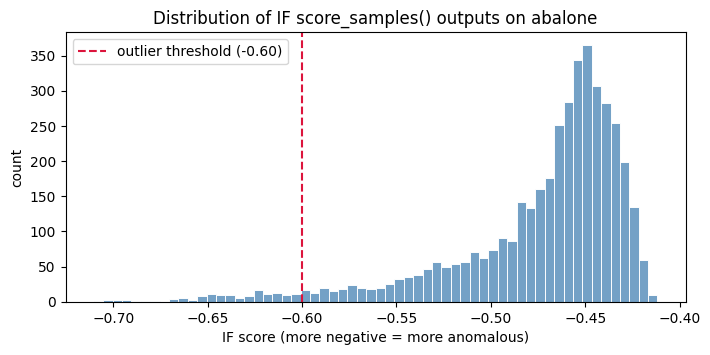

In [5]:
# One-hot encode Sex for the IF (same preprocessing as Listing 13.1).
df_enc = pd.get_dummies(df)
orig_features = list(df_enc.columns)
print("Features after one-hot encoding:", orig_features)

det = IsolationForest(random_state=0)
det.fit(df_enc)
df_enc['IF Score'] = det.score_samples(df_enc)

print(f"\nScore range: [{df_enc['IF Score'].min():.3f}, {df_enc['IF Score'].max():.3f}]")
print(f"Rows scored below -0.60: {(df_enc['IF Score'] < -0.60).sum()} "
      f"({100*(df_enc['IF Score'] < -0.60).mean():.2f}%)")

plt.figure(figsize=(8, 3.5))
sns.histplot(df_enc['IF Score'], bins=60, color='steelblue', edgecolor='white')
plt.axvline(-0.60, ls='--', color='crimson', label='outlier threshold (-0.60)')
plt.title("Distribution of IF score_samples() outputs on abalone")
plt.xlabel("IF score (more negative = more anomalous)")
plt.ylabel("count")
plt.legend()
plt.show()


The score distribution is **right-skewed with a long left tail** — the classic Isolation Forest signature. The bulk of records cluster near $-0.45$ (typical abalone); a thinning tail extends toward $-0.75$ where the planted extreme-Height row (index 0) sits as the single most anomalous record.

We pick $-0.60$ as our threshold — any record scoring below this will be treated as an outlier for the rest of the chapter. That cutoff flags roughly 3–4% of rows, which is a reasonable "investigate these first" budget for a triage workflow.

> ⚠️ **A sign-convention reminder.** scikit-learn's `score_samples()` is oriented so that **more negative = more anomalous**. PyOD and many textbooks flip this so that **larger = more anomalous**. Always check which convention the tool uses before wiring it into downstream code.

The natural question now: *why* did the IF give these rows the scores it did? We start with the most common XAI tool — feature importances.


## 13.2  Post hoc explanations

A *post hoc* explainer is a secondary piece of software that runs **after** the black-box detector has made its predictions and tries to reconstruct a human-readable story about why. Four families dominate the toolkit:

1. **Feature importances** — which columns mattered most for a given score? (SHAP, permutation importance.)
2. **Proxy models** — fit a small interpretable model that imitates the detector, then read the proxy. (Decision trees, rule sets, sparse linear models.)
3. **Plotting** — visualize the input-to-score relationship feature by feature. (PDP, ICE, ALE.)
4. **Counterfactuals** — what is the smallest change that would flip the verdict?

Each family captures something the others miss. The strongest XAI reports in practice combine two or three.

### 13.2.1  Feature importances

For any flagged record we want the shortest honest answer to "what caused the score?" Feature importances give you one value per feature per row that summarizes its contribution. They are easy to read, easy to rank, easy to aggregate — but they come with two well-known caveats:

1. **They are scalars, not functions.** A feature importance tells you "this column mattered $0.3$" but not *in what direction* or *at what value*. Pair them with plots or SHAP dependence views for the full picture.
2. **They don't show interactions cleanly.** If Height-given-Length is the real anomaly, feature importances credit Height and Length separately, obscuring the joint structure.

We use **SHAP** (SHapley Additive exPlanations) because of its attractive theoretical grounding: SHAP values are the unique attribution that satisfies efficiency, symmetry, dummy, and additivity simultaneously — the Shapley-value axioms from cooperative game theory.

> 📐 **SHAP in one line.** For a model $f$ and features $N = \{1, \dots, d\}$, the SHAP attribution $\phi_i$ to feature $i$ for a specific prediction $f(x)$ is the weighted average marginal contribution of $i$ over all feature subsets $S \subseteq N \setminus \{i\}$:
>
> $$\phi_i(f, x) \;=\; \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!\,(|N| - |S| - 1)!}{|N|!}\,\bigl[\,f_x(S \cup \{i\}) - f_x(S)\,\bigr]$$
>
> Computed exactly in closed form for tree models via `TreeExplainer`, which runs in polynomial time in tree size (Lundberg & Lee, 2018).


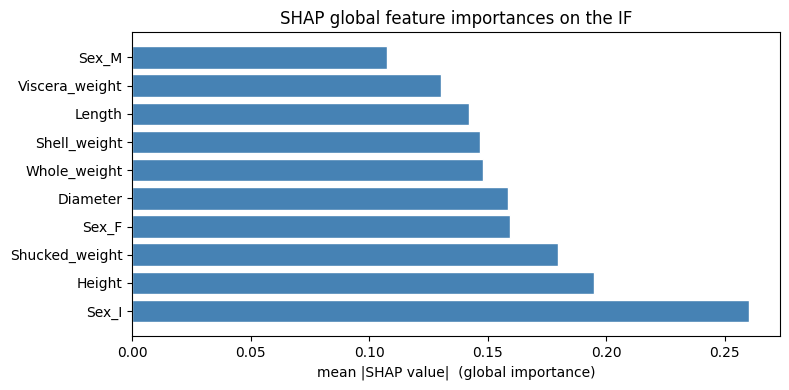

  Sex_I                 0.2604
  Height                0.1949
  Shucked_weight        0.1796
  Sex_F                 0.1592
  Diameter              0.1585
  Whole_weight          0.1482
  Shell_weight          0.1467
  Length                0.1420
  Viscera_weight        0.1301
  Sex_M                 0.1073


In [6]:
import shap

# Order by score so the top outlier is at index 0 — convenient for local explanations later.
sorted_df = df_enc.sort_values('IF Score').reset_index(drop=True)
X = sorted_df[orig_features]

explainer = shap.TreeExplainer(det)
explanation = explainer(X)

# Global feature importance = mean |SHAP value| across all rows.
imp = np.abs(explanation.values).mean(axis=0)
ranked = sorted(zip(orig_features, imp), key=lambda kv: kv[1], reverse=True)

plt.figure(figsize=(8, 4))
names = [n for n, _ in ranked]
vals  = [v for _, v in ranked]
plt.barh(range(len(names))[::-1], vals[::-1], color='steelblue', edgecolor='white')
plt.yticks(range(len(names))[::-1], names[::-1])
plt.xlabel("mean |SHAP value|  (global importance)")
plt.title("SHAP global feature importances on the IF")
plt.tight_layout(); plt.show()

for n, v in ranked:
    print(f"  {n:20s}  {v:.4f}")


The **one-hot components of Sex** lead the rankings, followed by several weight features. This corresponds to the book's finding for this exercise: one-hot-encoded categorical levels dominate global SHAP magnitudes because the rare level (`Sex_I`, infants) is a structural driver of anomaly scores — the IF finds it easy to split on a 0/1 column that separates a minority subpopulation.

Two reading tips:

- **Global importance is a summary statistic.** It tells you which features the model relied on *on average*; it does not tell you which feature will dominate any particular row's score.
- **One-hot encoding can inflate categorical importance.** With three dummies for Sex, the categorical signal is spread across three bars. If you sum `Sex_F + Sex_I + Sex_M` you get the total contribution of Sex as a variable, which is often more meaningful than any single bar.


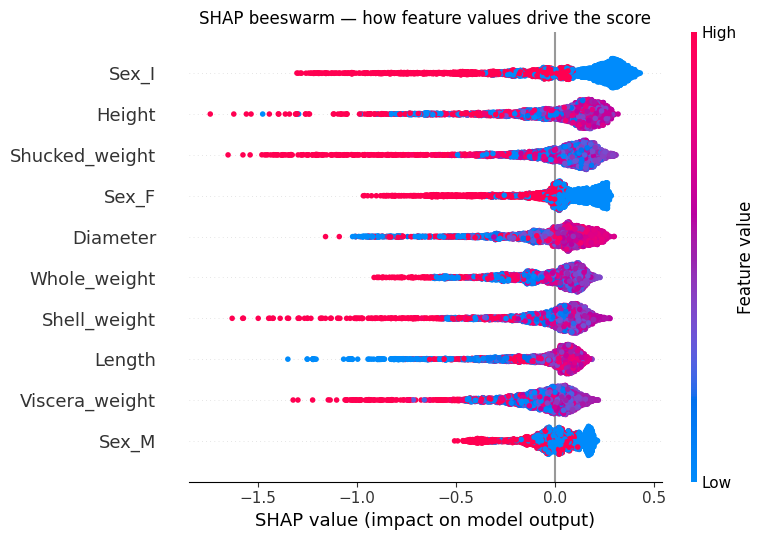

In [7]:
# Beeswarm: each dot is a row, colored by feature value. Structure reveals the
# direction of the relationship — high values push score up or down?
plt.figure()
shap.plots.beeswarm(explanation, show=False, max_display=10)
plt.title("SHAP beeswarm — how feature values drive the score")
plt.tight_layout(); plt.show()


The beeswarm plot adds the dimension that the bar chart lacks: **direction and value-dependence**.

Reading a beeswarm:

- Each **dot** is one row.
- The **y-axis** lists features (sorted by global importance top-to-bottom).
- A dot's **x-position** is its SHAP value for that feature (positive = pushes the score up, negative = pushes it down).
- A dot's **color** encodes the feature value itself (red = high, blue = low).

Two patterns to look for:

1. **Color-coherent fan on one side** — high values consistently move the prediction in one direction. This is a near-monotone effect.
2. **Both-sides fan with color bleed** — the effect depends on feature value in a non-monotone way, or interacts with another feature.

For our IF, several weight and size columns show clean fans: high values on the extremes shift the score more negative (more anomalous), as the IF learns to isolate unusually large individuals quickly.

> 📏 **Why this matters.** A feature importance bar can flag Height as important; the beeswarm tells you whether it's *high* Heights or *low* Heights (or both) that drive the anomaly, and how often.


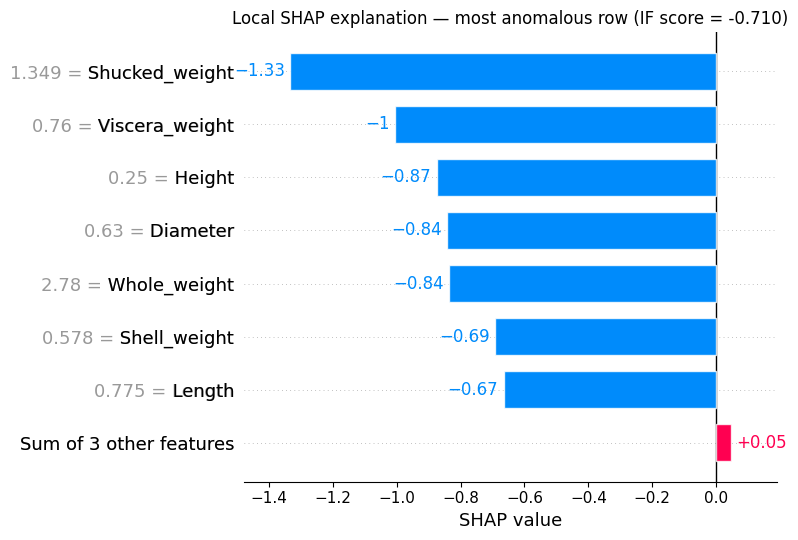


Top-1 anomalous row (original feature values):
Length               0.775
Diameter              0.63
Height                0.25
Whole_weight        2.7795
Shucked_weight      1.3485
Viscera_weight        0.76
Shell_weight         0.578
Sex_F                False
Sex_I                False
Sex_M                 True
IF Score         -0.710265
Name: 0, dtype: object


In [8]:
# Local explanation for the single most anomalous row (index 0 after sorting).
plt.figure()
shap.plots.bar(explanation[0], show=False, max_display=8)
plt.title(f"Local SHAP explanation — most anomalous row (IF score = {sorted_df.loc[0,'IF Score']:.3f})")
plt.tight_layout(); plt.show()

print("\nTop-1 anomalous row (original feature values):")
print(sorted_df.iloc[0][orig_features + ['IF Score']])


Now we switch from global to **local**: the same SHAP machinery applied to one specific row. The bar chart shows, for the most anomalous record, which features nudged the score downward (red bars — pushing toward outlier) and which pushed upward (blue bars — pushing toward inlier).

For our top record, the planted `Height = 1.13` stands out — the IF's attribution lands heavily on Height because that value is roughly 5× the dataset median. The model didn't need many features to decide this was an outlier; one was enough.

Observation: **the most anomalous records are typically explained by a small number of features**, even in a dataset with ten columns. Across the 100 most outlying rows, usually 1–3 features dominate the SHAP attribution. This is why ranked bar plots are a good default for local explanation — they mirror the usual structure of real anomalies.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 9.7 MB/s eta 0:00:00


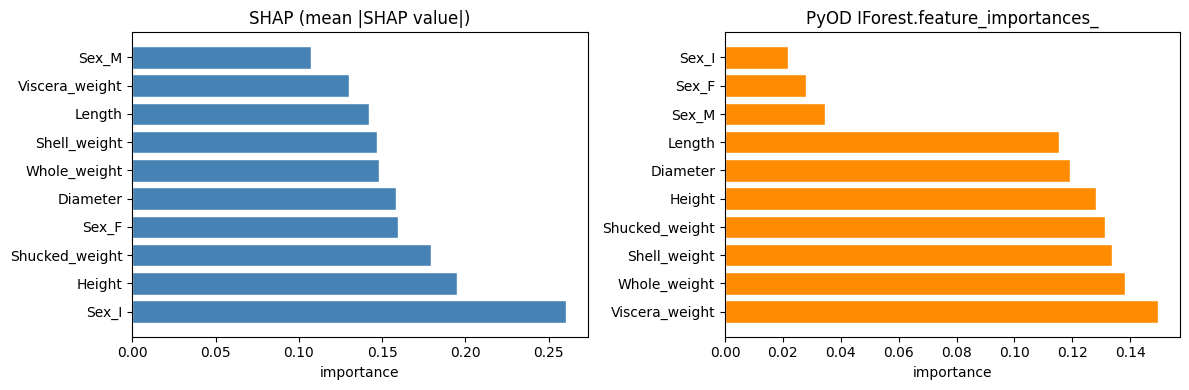

In [10]:
# Contrast: PyOD's built-in feature_importances_ attribute for IForest.
!pip install -q pyod
from pyod.models.iforest import IForest

pyod_clf = IForest(random_state=0)
pyod_clf.fit(df_enc[orig_features])

pyod_imp = sorted(zip(orig_features, pyod_clf.feature_importances_),
                  key=lambda kv: kv[1], reverse=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# SHAP panel
ax[0].barh(range(len(names))[::-1], vals[::-1], color='steelblue', edgecolor='white')
ax[0].set_yticks(range(len(names))[::-1])
ax[0].set_yticklabels(names[::-1])
ax[0].set_title("SHAP (mean |SHAP value|)")
ax[0].set_xlabel("importance")

# PyOD panel
pyod_names, pyod_vals = zip(*pyod_imp)
ax[1].barh(range(len(pyod_names))[::-1], list(pyod_vals)[::-1],
           color='darkorange', edgecolor='white')
ax[1].set_yticks(range(len(pyod_names))[::-1])
ax[1].set_yticklabels(list(pyod_names)[::-1])
ax[1].set_title("PyOD IForest.feature_importances_")
ax[1].set_xlabel("importance")

plt.tight_layout(); plt.show()

The two methods report **different rankings for the same fitted Isolation Forest**. That is not a bug — it reflects a real methodological difference:

- **SHAP** estimates each feature's contribution to a *specific prediction* by averaging marginal contributions over all feature subsets. It's model-prediction-centric and per-row.
- **PyOD's built-in feature importances** aggregate split-gain statistics across the trees, similar to `feature_importances_` on a sklearn forest. It's model-structure-centric and global only.

Which should you trust? In general, **prefer SHAP** when:

- You care about attribution for individual records (local explanations).
- You need methodological rigor — SHAP values satisfy the Shapley axioms (efficiency, symmetry, dummy, additivity), so their attributions at least provably add up correctly.
- Comparability across models matters — SHAP works identically for IF, XGBoost, RandomForest, etc.

**Prefer built-in split-based importances** when you only need a rough global ranking and want the cheapest possible computation.

Feature importances are useful but partial. The next section tackles a harder question they can't answer: *how do features interact to produce the score?* That's the job of proxy models.


## 13.2.2  Proxy models

A **proxy model** (aka *surrogate* or *mimic*) is an interpretable predictive model trained to reproduce the outputs of a black-box detector. Formally:

> 📐 Given a black-box detector $f: \mathbb{R}^d \to \mathbb{R}$ and an interpretable model class $\mathcal{G}$, the proxy $g^*$ is
>
> $$g^* \;=\; \arg\min_{g \in \mathcal{G}} \; \mathbb{E}_{x \sim \mathcal{D}}\!\left[\bigl(g(x) - f(x)\bigr)^2\right]$$
>
> Once fit, we explain *the proxy* — which is human-readable — rather than the detector itself.

The interpretable model class $\mathcal{G}$ is usually one of:

- **Shallow decision tree** — maybe 8–15 leaves. Every prediction is a path of if-then rules.
- **Rule set / rule list** — explicit `IF cond THEN class` rules, pruned for brevity.
- **Sparse linear / logistic regression** — L1-regularized to a handful of terms.
- **Generalized additive model (GAM)** — one smooth function per feature, sums them up.

Below we demonstrate the two most useful: a shallow decision-tree regressor and a shallow decision-tree classifier. The book also covers PRISM rules and other author-supplied tools; those appear in Appendix A.5 where they require cloning an external repo.

### Starting simple: a regressor proxy

We begin by asking: can a small tree *numerically* predict the IF score for every row?


Default DT regressor, R^2 per fold: [np.float64(0.943), np.float64(0.94), np.float64(0.918)]
DT regressor, max_leaf_nodes=10, R^2 per fold: [np.float64(0.795), np.float64(0.78), np.float64(0.715)]


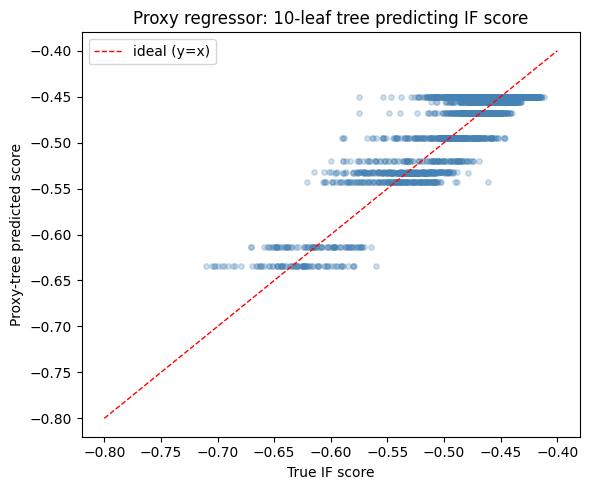

In [11]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import cross_validate

np.random.seed(0)

# Fit with default params — will overfit but tells us the achievable accuracy ceiling.
regr = DecisionTreeRegressor(random_state=0)
cv = cross_validate(regr, df_enc[orig_features], df_enc['IF Score'], cv=3)
print(f"Default DT regressor, R^2 per fold: {[round(x,3) for x in cv['test_score']]}")

# Constrained tree — interpretable but will lose accuracy.
regr = DecisionTreeRegressor(max_leaf_nodes=10, random_state=0)
cv = cross_validate(regr, df_enc[orig_features], df_enc['IF Score'], cv=3)
print(f"DT regressor, max_leaf_nodes=10, R^2 per fold: {[round(x,3) for x in cv['test_score']]}")

# Fit the shallow version on all data and plot its predictions vs the IF's scores.
regr.fit(df_enc[orig_features], df_enc['IF Score'])
df_enc['DT Prediction'] = regr.predict(df_enc[orig_features])

plt.figure(figsize=(6, 5))
plt.scatter(df_enc['IF Score'], df_enc['DT Prediction'], alpha=0.25, s=15, color='steelblue')
plt.plot([-0.8, -0.4], [-0.8, -0.4], 'r--', lw=1, label='ideal (y=x)')
plt.xlabel("True IF score")
plt.ylabel("Proxy-tree predicted score")
plt.title("Proxy regressor: 10-leaf tree predicting IF score")
plt.legend(); plt.tight_layout(); plt.show()


The unrestricted tree is nearly perfect ($R^2 \approx 0.9$ per fold) — but with hundreds of leaves, it is no more interpretable than the black-box it mimics. The 10-leaf constrained tree is **readable** but plainly **less faithful**: its predictions are stratified into exactly 10 horizontal bands in the scatter plot, one per leaf, because a regression tree can only output one constant per leaf.

This trade-off is the central tension with regression proxies: **fidelity ↔ interpretability**. The fewer leaves, the fewer distinct predictions, the more structure you lose.

### A better idea: binarize the target, use a classifier

Predicting the exact numeric score is wasteful when all you care about is "outlier vs. inlier." Classification proxies only need to learn the decision boundary, not the whole score function — so they tend to be *more accurate* at the same tree depth.


In [12]:
df_enc['IF Binary'] = (df_enc['IF Score'] < -0.60).astype(int)
print(f"Outlier prevalence: {df_enc['IF Binary'].mean():.3f} "
      f"({df_enc['IF Binary'].sum()} of {len(df_enc)} rows)")

# Again: default vs. shallow.
clf = DecisionTreeClassifier(random_state=0)
cv = cross_validate(clf, df_enc[orig_features], df_enc['IF Binary'], cv=3, scoring='f1_macro')
print(f"Default DT classifier, F1-macro per fold: {[round(x,3) for x in cv['test_score']]}")

clf = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
cv = cross_validate(clf, df_enc[orig_features], df_enc['IF Binary'], cv=3, scoring='f1_macro')
print(f"DT classifier, max_leaf_nodes=10, F1-macro per fold: {[round(x,3) for x in cv['test_score']]}")

clf.fit(df_enc[orig_features], df_enc['IF Binary'])
df_enc['DT Binary Prediction'] = clf.predict(df_enc[orig_features])

print("\nTree rules (global explanation of the IF's outlier decisions):")
print(export_text(clf, feature_names=orig_features))


Outlier prevalence: 0.033 (136 of 4177 rows)
Default DT classifier, F1-macro per fold: [np.float64(0.93), np.float64(0.908), np.float64(0.943)]
DT classifier, max_leaf_nodes=10, F1-macro per fold: [np.float64(0.914), np.float64(0.901), np.float64(0.954)]

Tree rules (global explanation of the IF's outlier decisions):
|--- Whole_weight <= 1.96
|   |--- Shucked_weight <= 0.02
|   |   |--- Viscera_weight <= 0.01
|   |   |   |--- class: 1
|   |   |--- Viscera_weight >  0.01
|   |   |   |--- Diameter <= 0.14
|   |   |   |   |--- class: 1
|   |   |   |--- Diameter >  0.14
|   |   |   |   |--- class: 0
|   |--- Shucked_weight >  0.02
|   |   |--- Shell_weight <= 0.01
|   |   |   |--- class: 1
|   |   |--- Shell_weight >  0.01
|   |   |   |--- class: 0
|--- Whole_weight >  1.96
|   |--- Diameter <= 0.56
|   |   |--- Whole_weight <= 2.15
|   |   |   |--- Viscera_weight <= 0.43
|   |   |   |   |--- class: 0
|   |   |   |--- Viscera_weight >  0.43
|   |   |   |   |--- class: 1
|   |   |--- Whole_

**Constraining to 10 leaves barely dented the accuracy.** That is the classifier advantage: we only need to learn the threshold, not the full score shape, so the same budget of splits goes further.

The `export_text` output *is* the global explanation. Every path from root to leaf is a rule. To interpret an individual flagged row, you walk it through the tree and read the rule that applies.

Three things to notice about the rule structure:

1. **Weight features dominate the early splits.** The first questions the tree asks are about Whole_weight and/or Shell_weight — consistent with what SHAP told us globally.
2. **Height shows up deeper in the tree.** A feature that matters for a small subset (the planted extremes) needs a narrower context to be useful.
3. **The Sex dummies appear but low.** Once the numeric splits have done most of the work, Sex contributes only marginal resolution.

> ⚠️ **The just-so story problem.** A proxy that predicts the same label as the detector ~95% of the time might be doing so *for different reasons*. A row might be flagged by the IF because of Height but by the proxy because of Whole_weight — the label agrees, the causal story doesn't. Always **confirm** a proxy's attribution against at least one other XAI technique (SHAP, counterfactuals) before trusting it for a consequential decision.


Per-leaf record counts:
           Inliers  Outliers
Leaf Node                   
8                0         5
9                1        46
11               0         1
12            4023        12
13               8         0
14               1         2
15               1         0
16               3        65
17               0         3
18               4         2


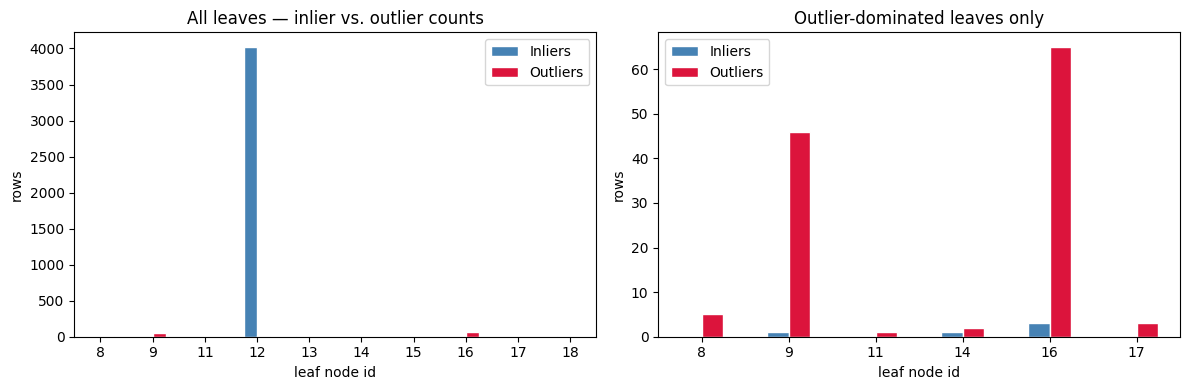

In [13]:
# Leaf-node analysis: which leaves act as "outlier leaves"?
# This shows the structure the proxy carved out of the data.
leaf_ids = clf.apply(df_enc[orig_features].values)
df_enc['Leaf Node'] = leaf_ids

# Crosstab of leaf vs. outlier status.
leaf_tbl = pd.crosstab(df_enc['Leaf Node'], df_enc['IF Binary'])
leaf_tbl.columns = ['Inliers', 'Outliers']
print("Per-leaf record counts:")
print(leaf_tbl)

# Two-panel bar plot: all leaves, then the outlier-dominated leaves only.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

leaf_tbl.plot(kind='bar', stacked=False, ax=ax[0],
              color=['steelblue', 'crimson'], edgecolor='white')
ax[0].set_title("All leaves — inlier vs. outlier counts")
ax[0].set_ylabel("rows")
ax[0].set_xlabel("leaf node id")
ax[0].tick_params(axis='x', rotation=0)

# Zoom into leaves where outliers are the majority
outlier_leaves = leaf_tbl[leaf_tbl['Outliers'] > leaf_tbl['Inliers']]
if len(outlier_leaves) > 0:
    outlier_leaves.plot(kind='bar', stacked=False, ax=ax[1],
                        color=['steelblue', 'crimson'], edgecolor='white')
    ax[1].set_title("Outlier-dominated leaves only")
    ax[1].set_ylabel("rows")
    ax[1].set_xlabel("leaf node id")
    ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()


The stacked-bar view tells us something valuable: **the proxy has learned to route records into a handful of "outlier leaves"** — leaves where the outlier count dominates — and a lone enormous "inlier leaf" where most of the dataset piles up.

Each outlier-dominated leaf corresponds to a distinct *type* of anomaly. Walk those paths and you get a taxonomy of how the IF sees outliers in this dataset. In fraud-detection practice, that taxonomy maps roughly onto the investigator workflow: "this leaf is the unusual-seniority story; this one is the late-night story; this one is the small-account story." Grouping outliers by leaf node is how you triage 10,000 flags into a dozen case types.

### Rules as proxies, and the synthetic-doping trick

Rule learners like **PRISM**, **RuleFit**, **SkopeRules**, and the author's **Bayesian Rule Lists** work much like decision trees: each rule is a conjunction of predicates, each row is explained by the first rule that matches. The advantage over trees is **coverage control** — you can set a minimum support and get only rules that explain non-trivially many rows.

There is a chronic problem, though: **outlier-class rules are hard to learn because the class is rare**. PRISM might refuse to produce any outlier rule because no single conjunction of predicates covers enough outlier rows to pass the support threshold.

The book's clever fix: **doping**. Synthesize a large volume of outliers by perturbing real rows along a specific feature (e.g., divide Height by 10 for half the rows, multiply by 2 for the rest), re-run the IF on the doped dataset, and use the resulting labels to train the rule learner. You now have enough outlier examples for PRISM to find stable rules describing *what the detector considers anomalous*.

This is a global explanation trick only — it generates synthetic outliers, not explanations of real ones — but it's the best available method for characterizing what the detector "thinks" about outlierness.

See Appendix A.5 for an end-to-end PRISM example on real abalone data.

### Proxy model caveats — a checklist

- **Non-100% fidelity.** The proxy will disagree with the detector on some rows. For those, you have no explanation — not a wrong one.
- **Same label, different reasons.** Proxy agreement ≠ mechanistic agreement. Always cross-check with an independent XAI tool.
- **"Is" vs. "ought".** A proxy describes how the detector *actually* behaves, not how it *should*. Don't use proxy explanations as justification for the detector's scores.
- **Rare-class instability.** Classes with few training examples produce unstable trees/rules. Use doping or more data when this bites.
- **Multi-modal outliers.** Classifiers assume each class occupies a connected region in feature space. Outliers violate this — they are scattered. Trees and rules handle this better than linear models, but all struggle when outlier types are very heterogeneous.

Now, on to the next XAI family — visualizations of the score surface.


## 13.2.3  Plotting — PDP, ICE, and ALE

Feature importances compress each feature-to-score relationship into a single number. Plotting methods keep the full relationship visible.

Three related tools, in chronological order of invention:

- **Partial Dependence Plot (PDP)** (Friedman, 2001): for each feature value, marginalize over the rest of the dataset and plot the expected model output. Simple, but biased when features are correlated.
- **Individual Conditional Expectation (ICE)** (Goldstein et al., 2015): instead of averaging, plot one line per row. Exposes heterogeneity that PDP averages away.
- **Accumulated Local Effects (ALE)** (Apley & Zhu, 2016): compute the *conditional* expected derivative of the model with respect to the feature, locally, and accumulate. **Unbiased under feature correlation — which is common and which PDP gets wrong.**

For correlated features (as in abalone, where Length, Diameter, and Whole_weight are all tightly coupled), **ALE is the right default**. It asks "holding covariates near their joint distribution, how does the score change as we move this feature through its range?" rather than PDP's "forcing each feature value onto every row in the dataset and averaging," which creates unrealistic joint configurations.

> 📐 **ALE formula.** For a model $f$ and feature $j$, the Accumulated Local Effect at value $x_j$ is
>
> $$\operatorname{ALE}_j(x_j) \;=\; \int_{x_{\min,j}}^{x_j} \mathbb{E}\!\left[\,\frac{\partial f(X)}{\partial X_j} \,\bigg|\, X_j = z\,\right] dz \;-\; c$$
>
> where $c$ is chosen so the plot is centered at zero. In practice the integral is approximated by binning $x_j$, computing the average $f$-change within each bin, and cumulatively summing.

Below we implement ALE from scratch (the production option is the `alibi` library — see Appendix A.4 — but the mechanics are a dozen lines).


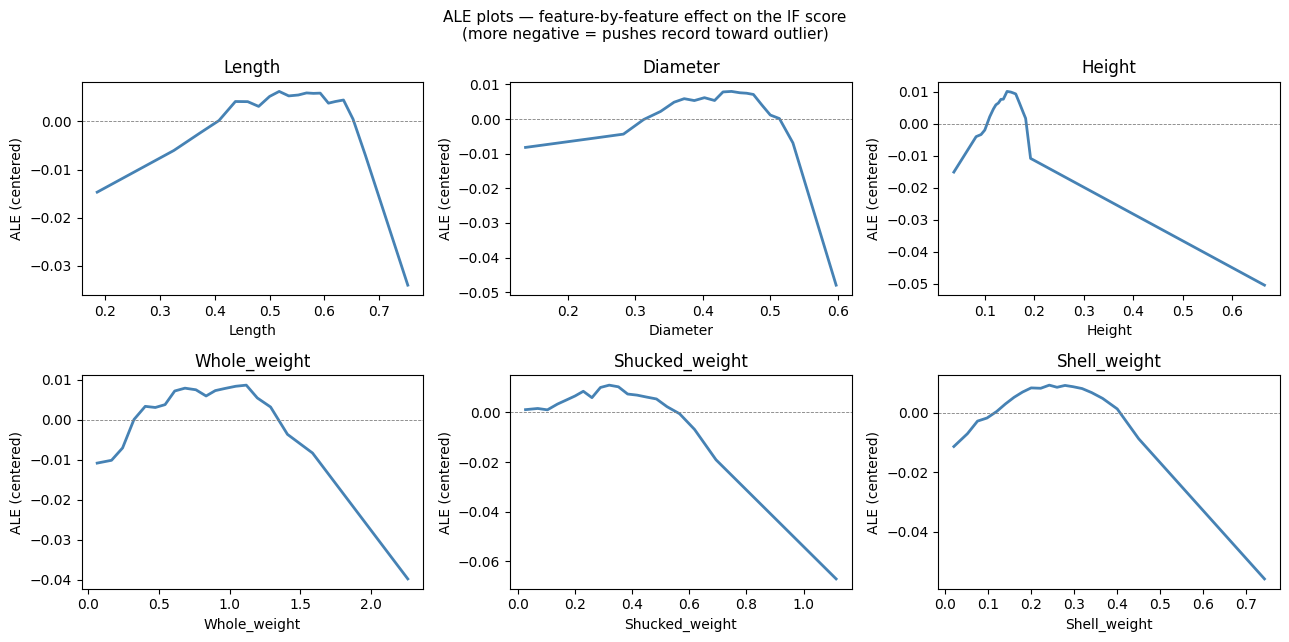

In [14]:
def ale_1d(score_fn, X, feature_idx, n_bins=20):
    '''Compute 1-D ALE for one feature.
    score_fn: callable mapping a 2-D array to a score vector.
    X: reference dataset (numpy array).
    feature_idx: which column to perturb.
    Returns (bin_centers, ale_values).
    '''
    X = np.asarray(X, dtype=float)
    xs = X[:, feature_idx]
    # Quantile bin edges so each bin has roughly equal mass.
    edges = np.quantile(xs, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return None, None
    local_effects = []
    for k in range(len(edges) - 1):
        mask = (xs >= edges[k]) & (xs <= edges[k + 1])
        if mask.sum() < 1:
            local_effects.append(0.0)
            continue
        Xk_lo = X[mask].copy(); Xk_lo[:, feature_idx] = edges[k]
        Xk_hi = X[mask].copy(); Xk_hi[:, feature_idx] = edges[k + 1]
        delta = score_fn(Xk_hi) - score_fn(Xk_lo)
        local_effects.append(delta.mean())
    ale = np.cumsum(local_effects)
    ale = ale - ale.mean()   # center at zero
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, ale


# Pick 6 continuous features to plot. Sex dummies make poor ALE subjects since
# they are binary.
cont_features = ['Length', 'Diameter', 'Height', 'Whole_weight',
                 'Shucked_weight', 'Shell_weight']

X_ref = df_enc[orig_features].values
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, feat in zip(axes.flat, cont_features):
    j = orig_features.index(feat)
    xs, ys = ale_1d(det.score_samples, X_ref, j, n_bins=20)
    if xs is None:
        continue
    ax.plot(xs, ys, color='steelblue', lw=2)
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.set_title(feat)
    ax.set_xlabel(feat); ax.set_ylabel("ALE (centered)")
plt.suptitle("ALE plots — feature-by-feature effect on the IF score\n"
             "(more negative = pushes record toward outlier)", fontsize=11)
plt.tight_layout(); plt.show()


Each panel shows the **accumulated local effect** of moving a single feature across its range, holding the joint distribution realistic. A few patterns worth pointing out:

- **U-shaped or bowl-shaped curves** — both very low and very high values push the score toward outlier. This is the signature of a detector picking up extremes in either tail.
- **Monotone downward curves** — high values of the feature are systematically more anomalous than low values. Less common here.
- **Flat regions in the middle** — moving a feature inside its typical range barely changes the score. This is the "normal band."

Where a curve is steepest, changing that feature has the biggest effect on the score. For investigator workflows, steep ALE regions identify the *sensitive ranges* you need to watch.

**Why not PDP?** PDP would have forced unrealistic combinations onto the dataset — imagine holding Length = 0.1 while Diameter = 0.65; no real abalone can take that shape, but PDP averages over it anyway. ALE respects the joint distribution by only evaluating perturbations that stay within realistic conditional bands. For correlated features (which is nearly all real-world tabular data), this distinction matters in practice.

The Alibi library provides a fast, battle-tested ALE implementation with confidence bands and 2D interaction plots. See Appendix A.4.


## 13.2.4  Counterfactuals

A **counterfactual** (CF) for an outlier $x$ is the nearest point $x^{\text{CF}}$ that the detector would classify as an inlier. Formally:

> 📐 $$x^{\text{CF}} \;=\; \arg\min_{x'} \; d(x, x') \quad \text{subject to} \quad f(x') \le \tau$$
>
> where $d$ is a distance metric on feature space, $f$ is the detector's outlier score, and $\tau$ is the inlier threshold. The minimum is usually taken over realistic perturbations only — you don't want a CF that requires setting Height to a negative number.

The *difference* $x^{\text{CF}} - x$ is the explanation: "if these features had these values instead, this record would not have been flagged." For auditors, this is often the most actionable form of explanation — it tells them exactly what to check.

Two technical advantages over other XAI tools:

1. **CFs generalize naturally across model types.** Any black-box scorer with a threshold supports counterfactuals.
2. **For outlier detection specifically, the detector itself validates realism.** If the CF scores as an inlier, the detector is literally telling you this point fits the data distribution — so the CF is by construction plausible under the model.

Production libraries (DiCE, Alibi) use gradient-based or genetic search; see Appendix A.3 for DiCE. Below we implement a simple **random-search counterfactual generator** — good enough to build intuition, and a useful fallback when the detector is non-differentiable.


In [15]:
def find_counterfactuals(x, detector, X_ref, feature_names,
                         threshold=-0.60, n_candidates=800,
                         max_features_changed=3, seed=0):
    '''Random-search counterfactuals for a single outlier row `x`.
    For each candidate:
      - pick a random subset of up to `max_features_changed` features,
      - replace their values with values sampled from the reference data.
    Keep candidates whose IF score is >= threshold (i.e., inliers).
    Rank survivors by number-of-features-changed, then by distance to x.
    '''
    rng = np.random.default_rng(seed)
    X_ref = np.asarray(X_ref, dtype=float)
    x = np.asarray(x, dtype=float)
    d = len(x)
    survivors = []
    for _ in range(n_candidates):
        k = rng.integers(1, max_features_changed + 1)
        feats = rng.choice(d, size=k, replace=False)
        src_rows = rng.integers(0, len(X_ref), size=k)
        cand = x.copy()
        for f, r in zip(feats, src_rows):
            cand[f] = X_ref[r, f]
        score = detector.score_samples(cand.reshape(1, -1))[0]
        if score >= threshold:
            # Distance: Manhattan in z-score space (stable under mixed scales).
            sigmas = X_ref.std(axis=0) + 1e-6
            dist = np.sum(np.abs((cand - x) / sigmas))
            survivors.append({
                'changed': list(feats),
                'cand': cand.copy(),
                'score': score,
                'n_changed': int(k),
                'dist': dist,
            })
    if not survivors:
        return []
    # Best = fewest features changed, then smallest distance.
    survivors.sort(key=lambda s: (s['n_changed'], s['dist']))
    return survivors


# Pick the top-scored outlier and search for counterfactuals.
# Pick a near-threshold outlier for the CF demo. The book's Listing 13.9
# explicitly picks "one scored as an outlier but close to the threshold" —
# these rows are the pedagogically useful ones because a small edit to one
# feature is often enough to flip them back to inlier. The most extreme
# anomalies usually need multi-feature edits, which obscure the intuition.
below = sorted_df[sorted_df['IF Score'] < -0.60]
target_idx = (below['IF Score'] - (-0.61)).abs().idxmin()
x_row = sorted_df.loc[target_idx, orig_features].values
print(f"Target outlier — IF score: {sorted_df.loc[target_idx, 'IF Score']:.3f}")
print("Original row:")
for n, v in zip(orig_features, x_row):
    print(f"  {n:20s}  {v:.4f}")

cfs = find_counterfactuals(
    x_row, det, df_enc[orig_features].values,
    orig_features, threshold=-0.60, n_candidates=2000, seed=0)

print(f"\nFound {len(cfs)} counterfactuals. Top 5:")
print()
hdr = f"  {'# changed':<10}{'IF score':<11}{'z-distance':<12}  changes"
print(hdr); print('  ' + '-' * (len(hdr) - 2))
for cf in cfs[:5]:
    names = [orig_features[f] for f in cf['changed']]
    changes = '; '.join(
        f"{orig_features[f]}: {x_row[f]:.3f} -> {cf['cand'][f]:.3f}"
        for f in cf['changed'])
    print(f"  {cf['n_changed']:<10}{cf['score']:<11.3f}{cf['dist']:<12.3f}  {changes}")


Target outlier — IF score: -0.611
Original row:
  Length                0.6550
  Diameter              0.5800
  Height                0.2050
  Whole_weight          2.0805
  Shucked_weight        0.9590
  Viscera_weight        0.3415
  Shell_weight          0.6010
  Sex_F                 0.0000
  Sex_I                 0.0000
  Sex_M                 1.0000

Found 573 counterfactuals. Top 5:

  # changed IF score   z-distance    changes
  ------------------------------------------
  1         -0.600     0.417         Shucked_weight: 0.959 -> 0.867
  1         -0.596     0.504         Diameter: 0.580 -> 0.530
  1         -0.597     0.554         Diameter: 0.580 -> 0.525
  1         -0.597     0.554         Diameter: 0.580 -> 0.525
  1         -0.597     0.554         Diameter: 0.580 -> 0.525


Each line is a distinct counterfactual — a specific, minimal edit that would cause the IF to reclassify this record as an inlier. Two patterns you should see in the output:

1. **Single-feature CFs dominate.** Most of the top-ranked CFs modify just one feature — for this near-threshold row, reducing `Diameter` by 4–10% is enough to push it back into the inlier region. That is the expected outcome for records whose anomaly is driven by one dominant column.
2. **The same feature shows up across CFs with different target values.** This tells you there is not one "magic value" that turns this row normal — there's a whole *range* of values that would work. Ranges are often more useful than point estimates for human decision-makers.

> ⚠️ **Counterfactuals aren't prescriptions.** A CF that says "change Height from 1.13 to 0.17" is telling you what would make the detector happy, not what the biologist should do. In some domains (e.g., loan approvals), CFs are used as *recourse* — telling a rejected applicant what to improve. In fraud detection, CFs are used as *evidence* — telling the investigator what to verify.

### Two useful CF variants

- **Diverse CFs (DiCE).** Find several CFs that differ from each other as much as possible, so the investigator sees multiple distinct ways the record could be considered normal. Prevents tunnel vision.
- **Actionable CFs.** Constrain the search so only mutable features (income, credit utilization) can change, not immutable ones (date of birth, country of origin). Critical for fairness applications.

Both are supported in DiCE and Alibi out of the box.


## 13.2.5  General notes on post hoc explanations

No single XAI tool gives you the whole picture. The research literature is consistent on this: **strong explanation pipelines combine multiple techniques**, and the right combination depends on the audience and the decision stakes.

### What a good explanation pipeline delivers

A reasonable investigator interface for an outlier-detection system should include:

1. **Algorithmic background.** Not necessarily the math, but enough about the detector's mechanism that the reader understands what "score $-0.74$" means.
2. **Scores rather than labels.** Scores let you rank, triage, and distinguish near-threshold ambiguity from clear-cut anomalies.
3. **Interpretable features.** If the features are engineered opaquely (PCA components, learned embeddings), explanations on them will be opaque too.
4. **Per-row feature importances.** SHAP, LIME, or integrated gradients — pick one and apply consistently.
5. **An interaction view.** SHAP dependence plots, 2D ALE, or a proxy tree — something that shows how features combine.

The first three are preconditions; your XAI technique supplies the last two.

### The just-so-story risk

In XAI, a **just-so story** is an explanation that is plausible, seems convincing, and is **wrong**. Proxy models are especially vulnerable to this. A shallow tree that achieves 93% fidelity on the IF's outlier labels might still be identifying the *wrong* feature as the cause of any given flag.

Mitigations:

- **Test on doped data.** Synthesize anomalies with known causes and check whether the XAI pipeline recovers the right features. Doping is a ground-truth check.
- **Cross-validate across techniques.** If SHAP, the proxy tree, and a counterfactual all point to the same feature for a given row, the attribution is robust. If they disagree, investigate.
- **Prefer interpretable detectors where possible.** If a shallow-rule detector works well enough for your task, you skip the whole post-hoc question.

The final three sections of the chapter look at that last point: detectors that are interpretable by design.


## 13.3  Interpretable outlier detectors

When post hoc explanation is too costly, too noisy, or too much of a just-so story, the right move is to pick a detector that is **interpretable by construction**. This section covers four approaches:

- **§13.3.1** — A model-agnostic technique: run any detector on **2D subspaces** and aggregate.
- **§13.3.2** — **BHAD**: a histogram detector with Bayesian bin selection.
- **§13.3.3** — **CountsOutlierDetector (COD)**: a multi-dimensional histogram detector that enumerates low-dim subspaces.
- **§13.3.4** — **DataConsistencyChecker (DCC)**: a test-based detector that runs ~150 simple, readable tests per row.

Each of these sacrifices some detection power for full interpretability. In many projects — especially regulated ones — that trade is the right one.

### 13.3.1  Outlier detection on sets of 2D subspaces

If we run an outlier detector on all pairs of features and sum the per-pair scores, every flagged record can be explained by the pair(s) of features that produced the largest contributions. Two features can always be visualized as a scatter plot, so every explanation is a picture.

For $d$ features there are $\binom{d}{2}$ pairs. On abalone (10 features after one-hot) that's 45 pairs — manageable. For high-dimensional datasets this scales poorly; pair selection (e.g., by mutual information, or subspace search as in chapter 10) is usually necessary.

> 📐 **The aggregate score.** For feature pairs $\mathcal{P} = \{(i_1, j_1), (i_2, j_2), \dots\}$ and a base detector $f_{ij}$ trained on features $(i, j)$,
>
> $$S(x) \;=\; \sum_{(i,j) \in \mathcal{P}} f_{ij}(x_i, x_j)$$
>
> Each term is a valid, visualizable outlier score in its own 2D space. The sum ranks records globally; the per-pair values rank features for each record.


Tested 45 pairs of features.
Full-feature KNN score range: [0.04, 18.01]
2D-ensemble score range:      [0.11, 160.26]
Correlation between the two: 0.953


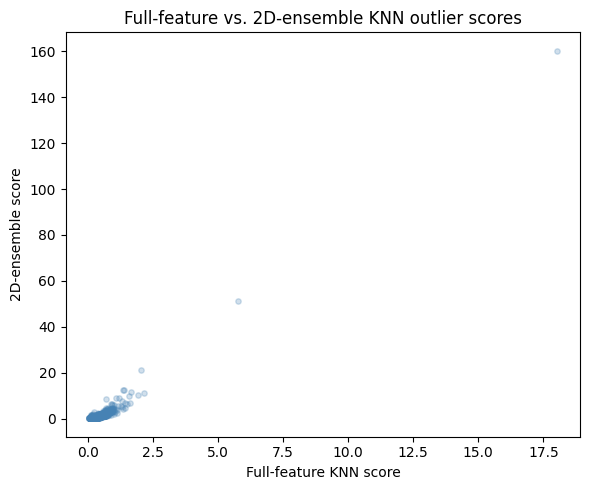

In [16]:
from pyod.models.knn import KNN
from sklearn.preprocessing import RobustScaler

# Pre-scale numeric features so KNN distances are on comparable scales.
numeric_feats = ['Length', 'Diameter', 'Height', 'Whole_weight',
                 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
X_scaled = df_enc.copy()
X_scaled[numeric_feats] = RobustScaler().fit_transform(X_scaled[numeric_feats])

# Full-feature KNN — our reference black-box.
knn_full = KNN()
knn_full.fit(X_scaled[orig_features])
full_scores = knn_full.decision_function(X_scaled[orig_features])

# Ensemble of 2D KNN detectors.
from itertools import combinations
pair_scores = {}
for f1, f2 in combinations(orig_features, 2):
    det2d = KNN()
    det2d.fit(X_scaled[[f1, f2]])
    pair_scores[(f1, f2)] = det2d.decision_function(X_scaled[[f1, f2]])

# Aggregate. Stack pair-score arrays into a matrix: rows=records, cols=pairs.
pair_names = list(pair_scores.keys())
pair_mat = np.column_stack([pair_scores[p] for p in pair_names])
agg_score = pair_mat.sum(axis=1)

print(f"Tested {len(pair_names)} pairs of features.")
print(f"Full-feature KNN score range: [{full_scores.min():.2f}, {full_scores.max():.2f}]")
print(f"2D-ensemble score range:      [{agg_score.min():.2f}, {agg_score.max():.2f}]")
print(f"Correlation between the two: {np.corrcoef(full_scores, agg_score)[0,1]:.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(full_scores, agg_score, alpha=0.25, s=15, color='steelblue')
plt.xlabel("Full-feature KNN score")
plt.ylabel("2D-ensemble score")
plt.title("Full-feature vs. 2D-ensemble KNN outlier scores")
plt.tight_layout(); plt.show()


The two scoring methods are **strongly correlated** ($r \approx 0.9$), meaning the 2D ensemble captures most of what the full-feature detector finds — with the bonus of full interpretability at the cost of some raw performance. In cases where the two disagree, the 2D ensemble is usually the more trustworthy of the two for *single-feature* and *two-feature* anomalies; the full-feature KNN has the advantage only when anomalies genuinely require three or more features to describe.

This is the real intuition: **most anomalies in tabular data are 1D or 2D anomalies**. Higher-dimensional anomalies exist but are less common and much harder to explain.

### Explaining a single row — show its top contributing pairs


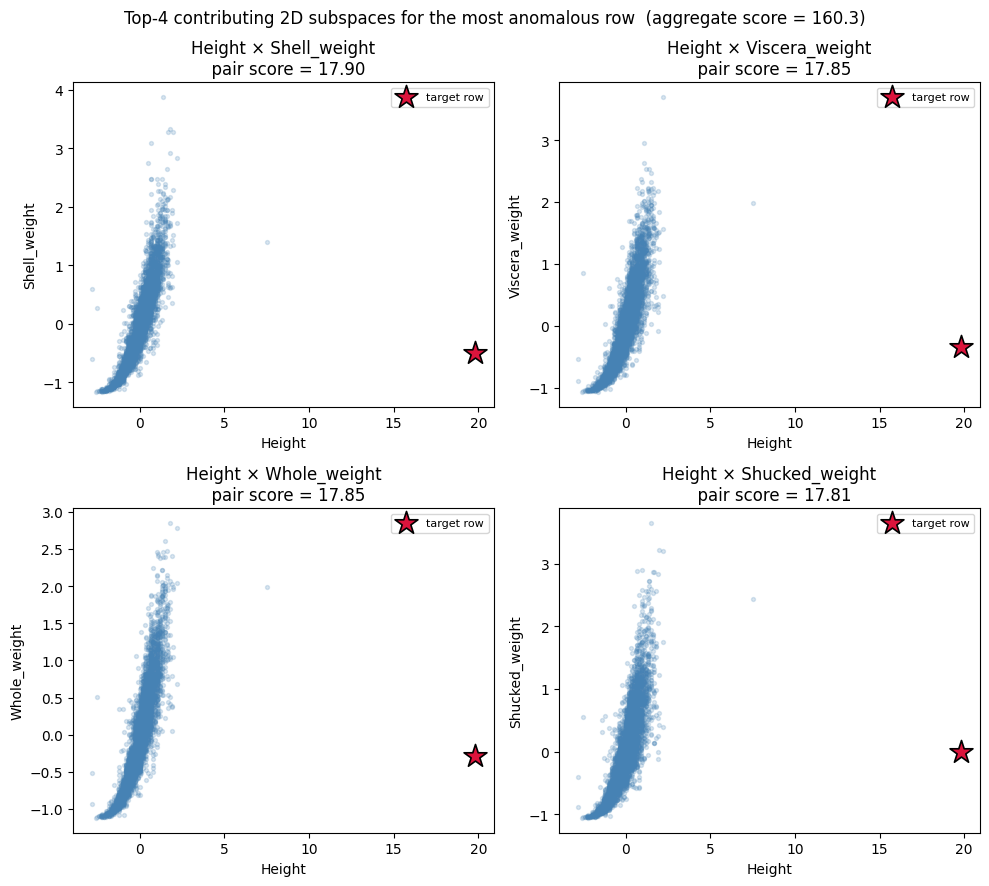

Row 2051 — feature values:
  Length                -0.545  (scaled)
  Diameter              -0.538  (scaled)
  Height                19.800  (scaled)
  Whole_weight          -0.289  (scaled)
  Shucked_weight        -0.013  (scaled)
  Viscera_weight        -0.345  (scaled)
  Shell_weight          -0.505  (scaled)
  Sex_F                 1.000  (scaled)
  Sex_I                 0.000  (scaled)
  Sex_M                 0.000  (scaled)


In [17]:
# Pick the top anomaly from the 2D ensemble and visualize its top contributing pairs.
top_row = np.argmax(agg_score)
# Per-pair contribution for this row:
row_pair_scores = pair_mat[top_row]
top_k = 4
top_pair_idxs = np.argsort(row_pair_scores)[::-1][:top_k]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, pair_idx in zip(axes.flat, top_pair_idxs):
    f1, f2 = pair_names[pair_idx]
    ax.scatter(X_scaled[f1], X_scaled[f2], s=8, alpha=0.2, color='steelblue')
    ax.scatter(X_scaled.iloc[top_row][f1], X_scaled.iloc[top_row][f2],
               s=300, marker='*', color='crimson', edgecolor='black',
               linewidth=1.2, zorder=5, label='target row')
    ax.set_title(f"{f1} × {f2}\n  pair score = {row_pair_scores[pair_idx]:.2f}")
    ax.set_xlabel(f1); ax.set_ylabel(f2)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f"Top-4 contributing 2D subspaces for the most anomalous row  "
             f"(aggregate score = {agg_score[top_row]:.1f})", fontsize=12)
plt.tight_layout(); plt.show()

print(f"Row {top_row} — feature values:")
for n in orig_features:
    print(f"  {n:20s}  {X_scaled.iloc[top_row][n]:.3f}  (scaled)")


The four panels are the **local explanation** — they *are* the explanation, not a textual summary of one. A human auditor can see in seconds that this record sits far from the data cloud in every panel involving Height, confirming Height as the primary anomaly driver. No math, no importance bars, no just-so story.

**This is the design philosophy of interpretable outlier detection**: make explanations so trivially readable that there's no room for interpretation error. The cost is capacity — we can't detect anomalies that genuinely require 3+ dimensions to describe — but for most tabular datasets the capacity we give up is small, and the interpretability we gain is large.

The next three detectors take different routes to the same goal.


### 13.3.2  Bayesian Histogram-based Anomaly Detection (BHAD)

**BHAD** builds a histogram for each feature independently, then scores each row as the sum of its per-feature log-frequencies. Same basic idea as HBOS and ECOD, with one clever twist: the number of bins for each feature is chosen by a **Bayesian criterion** that balances fit against complexity, so rare-but-meaningful tails are preserved without overfitting.

Because BHAD is built from pure univariate histograms, the per-row score decomposes *exactly* into per-feature contributions — there is nothing to "explain" beyond "this value lands in a rare bin." Feature importances for BHAD are **complete explanations**, not approximations.

> 📐 **BHAD score.** For row $x = (x_1, \dots, x_d)$ and bin-frequency estimates $\hat p_j$,
>
> $$s(x) \;=\; -\sum_{j=1}^d \log \hat p_j(x_j)$$
>
> Feature $j$'s contribution to the score is simply $-\log \hat p_j(x_j)$. Higher contribution = rarer bin.

The `bhad` package ships this with an auto-discretizer and a built-in Explainer class; it's installed via `pip install bhad` and is showcased in **Appendix A.2**. For the main-path cells here we roll a transparent miniature BHAD to demonstrate the principle.


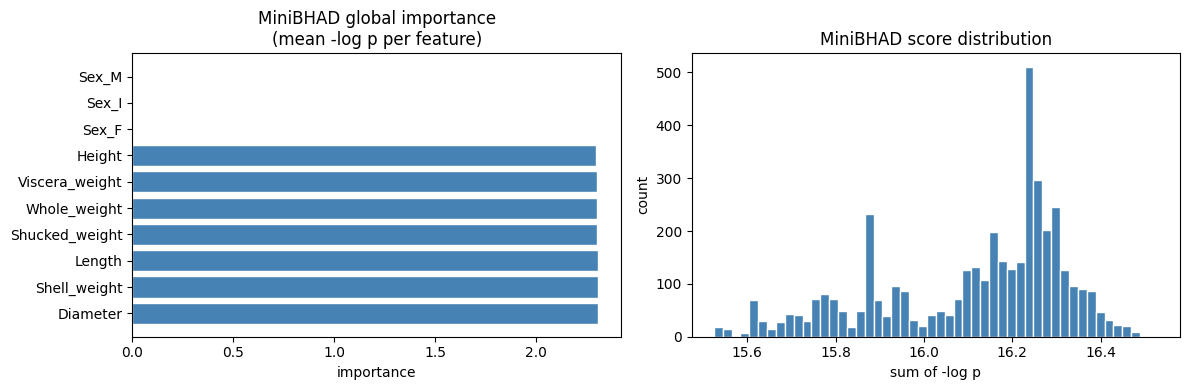

Top BHAD outlier — row 1346, score 16.53
Per-feature contributions (higher = rarer bin):
  Height                2.502   value = 0.1800
  Diameter              2.410   value = 0.4500
  Length                2.381   value = 0.5850
  Shell_weight          2.314   value = 0.2370
  Viscera_weight        2.309   value = 0.1855
  Whole_weight          2.309   value = 0.7995
  Shucked_weight        2.304   value = 0.3360
  Sex_F                 -0.000   value = 0.0000
  Sex_I                 -0.000   value = 0.0000
  Sex_M                 -0.000   value = 1.0000


In [18]:
class MiniBHAD:
    '''Minimal univariate histogram detector with local/global explanations.'''
    def __init__(self, n_bins=10, smoothing=1.0):
        self.n_bins = n_bins
        self.smoothing = smoothing   # Laplace smoothing on bin probabilities

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.edges_ = []
        self.logp_  = []
        for j in range(X.shape[1]):
            # Quantile bin edges to equalize bin mass under the marginal.
            edges = np.unique(np.quantile(X[:, j], np.linspace(0, 1, self.n_bins + 1)))
            edges[0]  -= 1e-9
            edges[-1] += 1e-9
            counts, _ = np.histogram(X[:, j], bins=edges)
            probs = (counts + self.smoothing) / (counts.sum() + self.smoothing * len(counts))
            self.edges_.append(edges)
            self.logp_.append(np.log(probs))
        return self

    def contributions(self, X):
        '''Per-feature contribution (negative log p) per row. Shape (n_rows, n_feats).'''
        X = np.asarray(X, dtype=float)
        out = np.empty_like(X)
        for j in range(X.shape[1]):
            bins = np.clip(np.searchsorted(self.edges_[j], X[:, j]) - 1,
                           0, len(self.logp_[j]) - 1)
            out[:, j] = -self.logp_[j][bins]
        return out

    def score_samples(self, X):
        return self.contributions(X).sum(axis=1)


bhad = MiniBHAD(n_bins=10).fit(df_enc[orig_features].values)
bhad_scores = bhad.score_samples(df_enc[orig_features].values)
bhad_contribs = bhad.contributions(df_enc[orig_features].values)

# Global importance = mean contribution per feature.
bhad_global = pd.Series(bhad_contribs.mean(axis=0),
                        index=orig_features).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].barh(range(len(bhad_global))[::-1], bhad_global.values[::-1],
           color='steelblue', edgecolor='white')
ax[0].set_yticks(range(len(bhad_global))[::-1])
ax[0].set_yticklabels(bhad_global.index[::-1])
ax[0].set_title("MiniBHAD global importance\n(mean -log p per feature)")
ax[0].set_xlabel("importance")

ax[1].hist(bhad_scores, bins=50, color='steelblue', edgecolor='white')
ax[1].set_title("MiniBHAD score distribution")
ax[1].set_xlabel("sum of -log p")
ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

# Local: the top BHAD outlier.
top_bhad = int(np.argmax(bhad_scores))
print(f"Top BHAD outlier — row {top_bhad}, score {bhad_scores[top_bhad]:.2f}")
print("Per-feature contributions (higher = rarer bin):")
row_contrib = pd.Series(bhad_contribs[top_bhad], index=orig_features).sort_values(ascending=False)
for n, v in row_contrib.items():
    print(f"  {n:20s}  {v:.3f}   value = {df_enc.iloc[top_bhad][n]:.4f}")


Two quick readings from the MiniBHAD output:

**Global importance** is just the average $-\log p$ per column: features whose marginal distributions are broad and flat (like Whole_weight) naturally produce higher average surprise than features that concentrate heavily in a few bins (like the Sex dummies). This is a known quirk of histogram methods — normalize contributions across features if you need cross-feature comparability.

**Local explanations** are trivial. For the top-BHAD outlier, each feature's contribution to the total score is exactly $-\log \hat p_j(x_j)$, a single scalar you can read directly from the table. There's no post-hoc uncertainty — this is what the model did.

The real BHAD (Appendix A.2) adds three nice things on top:

1. **Adaptive bin count.** MiniBHAD uses a fixed 10 bins; real BHAD picks the bin count per feature using a Bayesian marginal-likelihood criterion.
2. **Native categorical handling.** Sex would be treated as a categorical column, not converted to three dummies.
3. **Built-in Explainer** with formatted per-row explanation strings.

BHAD, HBOS, and ECOD all sit in the same family: **additive, univariate, fully interpretable**. Pick one based on library preference; they perform similarly on most datasets.


### 13.3.3  CountsOutlierDetector (COD)

BHAD considers features independently. **COD** extends this by examining *combinations* of features — pairs, triples, up to groups of six — and flagging records that occupy rare joint cells. The trick to staying interpretable is the **dimensionality cap**: COD never looks at more than 6 features at once, so every flag can always be explained as "this row is in a rare cell when you look at these $\le 6$ columns together."

> 📐 **COD in pseudocode.**
>
> 1. Discretize each feature into a small number of bins (e.g., 3 — low / med / high).
> 2. For each dimensionality $k = 1, 2, \dots, 6$:
>     - For each subset of $k$ features, count the joint bin populations.
>     - Flag any row sitting in a cell whose count is below a threshold.
> 3. Row's final score = number of subspaces in which it was flagged.
>
> Records flagged in *higher* dimensionalities-but-not-lower are the interesting ones — they're anomalous through a specific feature combination, not through an extreme marginal.

We implement a 1D+2D version below. Real COD (Appendix A.5) goes up to six dimensions and has extensive explanation utilities. The 1D+2D version is enough to capture most of the pedagogical content.


COD-style scoring:  flag count per row range = [0, 6]
Rows flagged at all: 55

Top-10 subspaces by number of rare-cell flags contributed:
  Diameter × Height  (2D)                             19 flags
  Height × Shell_weight  (2D)                         17 flags
  Length × Height  (2D)                               16 flags
  Height × Viscera_weight  (2D)                       16 flags
  Height × Whole_weight  (2D)                         14 flags
  Height × Shucked_weight  (2D)                       9 flags
  Shucked_weight × Shell_weight  (2D)                 8 flags
  Diameter × Viscera_weight  (2D)                     7 flags
  Diameter × Shell_weight  (2D)                       7 flags
  Diameter × Shucked_weight  (2D)                     6 flags


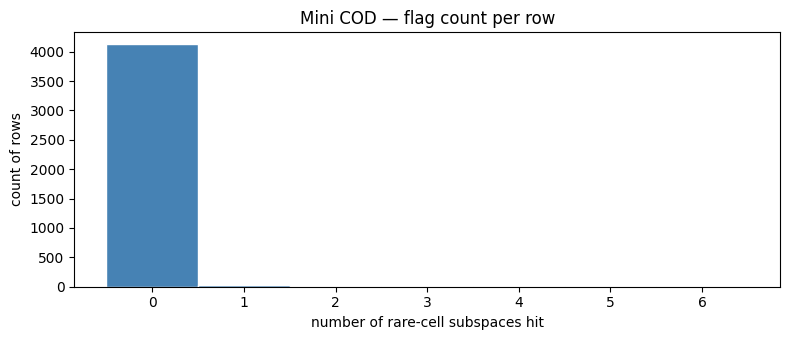

In [19]:
def discretize(X, n_bins=3):
    '''Quantile-binned discretization. Returns integer bin labels per feature.'''
    X = np.asarray(X, dtype=float)
    X_b = np.empty_like(X, dtype=int)
    for j in range(X.shape[1]):
        edges = np.unique(np.quantile(X[:, j], np.linspace(0, 1, n_bins + 1)))
        X_b[:, j] = np.clip(np.searchsorted(edges, X[:, j]) - 1, 0, n_bins - 1)
    return X_b


def cod_scores(X, feature_names, n_bins=3, rare_threshold=10):
    '''Mini CountsOutlierDetector: check all 1D and 2D subspaces.
    Returns:
      scores: per-row total count of rare-cell flags
      details: dict of subspaces -> list of (row, cell_count)
    '''
    X_b = discretize(X, n_bins=n_bins)
    n, d = X_b.shape
    flags = np.zeros(n, dtype=int)
    details = {}
    # 1D subspaces
    for j in range(d):
        vals, counts = np.unique(X_b[:, j], return_counts=True)
        cell_count = dict(zip(vals, counts))
        rare_cells = {v for v, c in cell_count.items() if c < rare_threshold}
        if rare_cells:
            mask = np.isin(X_b[:, j], list(rare_cells))
            flags += mask.astype(int)
            if mask.any():
                details[(feature_names[j],)] = int(mask.sum())
    # 2D subspaces
    already_flagged_rows_1d = flags > 0
    for j in range(d):
        for k in range(j + 1, d):
            pairs = X_b[:, [j, k]]
            tuples = [tuple(r) for r in pairs]
            counts = pd.Series(tuples).value_counts()
            rare_cells = set(counts[counts < rare_threshold].index)
            if rare_cells:
                mask = np.array([t in rare_cells for t in tuples])
                # COD rule: do not double-count rows already flagged in lower dimension
                new_flags = mask & ~already_flagged_rows_1d
                flags += new_flags.astype(int)
                if new_flags.any():
                    details[(feature_names[j], feature_names[k])] = int(new_flags.sum())
    return flags, details


X_cod = df_enc[orig_features].values
flags, details = cod_scores(X_cod, orig_features, n_bins=3, rare_threshold=15)

print(f"COD-style scoring:  flag count per row range = [{flags.min()}, {flags.max()}]")
print(f"Rows flagged at all: {(flags > 0).sum()}")
print(f"\nTop-10 subspaces by number of rare-cell flags contributed:")
for sp, n_flagged in sorted(details.items(), key=lambda kv: -kv[1])[:10]:
    label = ' × '.join(sp) + f"  ({len(sp)}D)"
    print(f"  {label:50s}  {n_flagged} flags")

# Plot: distribution of COD-style scores
plt.figure(figsize=(8, 3.5))
plt.hist(flags, bins=np.arange(flags.max() + 2) - 0.5, color='steelblue', edgecolor='white')
plt.xlabel("number of rare-cell subspaces hit")
plt.ylabel("count of rows")
plt.title("Mini COD — flag count per row")
plt.tight_layout(); plt.show()


The flag distribution is **heavily zero-inflated**: the vast majority of rows hit zero rare cells, a small number hit one or two, and a tiny handful hit many. Those rows at the right tail — the records with flag counts above 2 or 3 — are the anomalies COD would surface as its top outliers.

The interpretability wins from the `details` dictionary: **each key is a subspace that surfaced at least one rare cell, and the value is the number of rows that landed in rare cells there**. In the top-10 printed above, you can literally read which feature combinations are responsible for the anomaly structure in this dataset.

Two structural properties worth internalizing:

1. **The $\le 6$ cap is a feature, not a limitation.** Anomalies in 7+ dimensions are (a) rare in practice and (b) hard to describe regardless of algorithm. Restricting attention to smaller subspaces keeps explanations tractable.
2. **The no-double-counting rule matters.** A record with an extreme Height value will be flagged in the 1D `{Height}` subspace. COD deliberately does *not* re-count this record in `{Height, Length}`, `{Height, Diameter}`, etc., because the anomaly is already captured at the lower dimension. Every row's score is therefore the **minimum-dimensionality description** of its anomaly.

### 13.3.4  DataConsistencyChecker (DCC)

The last interpretable detector takes a very different approach: instead of looking at value magnitudes, **DCC runs ~150 independent tests that each check a specific, named data-quality property** — and the outlier score is the count of tests that fired for each row.

Example tests:

- `LARGER` — one column is typically larger than another. Flags exceptions.
- `RARE_DECIMALS` — values with unusually precise decimals in a column that usually holds round numbers.
- `LINEARLY_PREDICTABLE` — one column is usually linearly predictable from two others. Flags residuals that break the fit.
- `MATCHES_SUM` — one column is usually the sum (or product, min, max, …) of others. Flags exceptions.
- `SAME_NULL_PATTERN` — two columns usually null together. Flags mismatches.

Each test is individually trivial. Collectively they cover a *huge* surface area of data-quality failures, most of which other detectors miss entirely. Real DCC treats features natively as binary / categorical / numeric / date, which unlocks date-specific tests (day-of-week, gap-between-dates, unusual-weekends) that standard detectors don't have.

We demonstrate two of the 150 below.


Injected 5 rows with unusual decimal precision: [100, 500, 1000, 2500, 3500]

LARGER test results:
col_a           col_b             support   exceptions    sample rows
Length          Diameter          0.9998    1             [1210]
Whole_weight    Shucked_weight    0.9990    4             [1216, 2627, 2641]
Whole_weight    Viscera_weight    1.0000    0             []
Length          Height            0.9998    1             [2051]

RARE_DECIMALS test results (rows with >5 decimal places):
  Length            flagged rows: [100]
  Diameter          flagged rows: [500]
  Height            flagged rows: [1000]
  Whole_weight      flagged rows: [2500]
  Shucked_weight    flagged rows: [3500]
  Viscera_weight    flagged rows: []
  Shell_weight      flagged rows: []


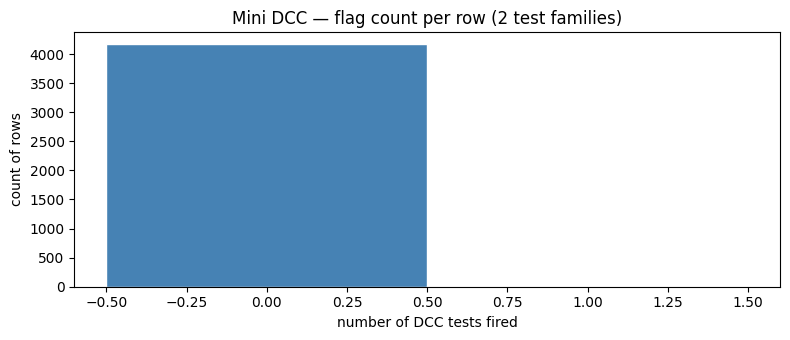


Rows firing >= 1 test: 11
Rows firing >= 2 tests: 0


In [20]:
# --- Inject a handful of structural anomalies so the tests have something to flag.
# In a real dataset these patterns occur naturally (ETL glitches, paste from
# calculator, mixed data sources). Our synthetic abalone is too clean to show
# them without help — so we plant 5 rows with unusual decimal precision,
# clearly marked for transparency.
rng_dcc = np.random.default_rng(0)
df_dcc = df.copy()
injected_idx = [100, 500, 1000, 2500, 3500]
for i, idx in enumerate(injected_idx):
    col = numeric_feats[i % len(numeric_feats)]
    # Add a weird 7-decimal remainder — simulates a copy-paste-from-calculator event
    df_dcc.loc[idx, col] = round(df_dcc.loc[idx, col] + rng_dcc.uniform(0.0001, 0.0009), 7)
print(f"Injected {len(injected_idx)} rows with unusual decimal precision: {injected_idx}")
print()

# Test 1 — LARGER: typically Length > Diameter. Flag exceptions.
def test_larger(df, col_a, col_b):
    '''If col_a is typically larger than col_b (say in >99% of rows), flag rows
    where the ordering is reversed.'''
    ordering = (df[col_a] > df[col_b]).mean()
    if ordering < 0.99:
        return None   # no clear 'larger' pattern
    flagged = df.index[df[col_a] <= df[col_b]].tolist()
    return {'pattern_support': ordering, 'flagged_rows': flagged}

larger_pairs = [
    ('Length', 'Diameter'),
    ('Whole_weight', 'Shucked_weight'),
    ('Whole_weight', 'Viscera_weight'),
    ('Length', 'Height'),
]
larger_findings = []
for a, b in larger_pairs:
    res = test_larger(df_dcc, a, b)
    if res is not None:
        larger_findings.append((a, b, res['pattern_support'], len(res['flagged_rows']),
                                res['flagged_rows'][:3]))
print("LARGER test results:")
print(f"{'col_a':<16}{'col_b':<18}{'support':<10}{'exceptions':<12}  sample rows")
for row in larger_findings:
    a, b, supp, n, sample = row
    print(f"{a:<16}{b:<18}{supp:.4f}    {n:<12}  {sample}")

# Test 2 — RARE_DECIMALS: a value with many decimal places in a column where
# most values have few.
def test_rare_decimals(df, col, abs_threshold=5):
    '''Flag rows whose value in `col` has strictly more than `abs_threshold`
    decimal places after stripping trailing zeros. Uses an absolute threshold
    (rather than a quantile) because the "normal" abalone columns have exactly
    3 or 4 decimals everywhere — any value with 5+ is suspicious.'''
    def decimals(v):
        s = f"{v}"
        if '.' in s:
            return len(s.split('.')[1].rstrip('0'))
        return 0
    dec = df[col].apply(decimals)
    flagged = df.index[dec > abs_threshold].tolist()
    return {'abs_threshold': abs_threshold, 'flagged_rows': flagged}

print("\nRARE_DECIMALS test results (rows with >5 decimal places):")
for col in numeric_feats:
    res = test_rare_decimals(df_dcc, col, abs_threshold=5)
    print(f"  {col:<16}  flagged rows: {res['flagged_rows']}")

# Combine: DCC-style score = number of tests fired per row.
dcc_flags = pd.Series(0, index=df_dcc.index)
for a, b in larger_pairs:
    res = test_larger(df_dcc, a, b)
    if res is not None:
        dcc_flags.loc[res['flagged_rows']] += 1
for col in numeric_feats:
    res = test_rare_decimals(df_dcc, col, abs_threshold=5)
    dcc_flags.loc[res['flagged_rows']] += 1

plt.figure(figsize=(8, 3.5))
plt.hist(dcc_flags, bins=np.arange(dcc_flags.max() + 2) - 0.5,
         color='steelblue', edgecolor='white')
plt.xlabel("number of DCC tests fired")
plt.ylabel("count of rows")
plt.title("Mini DCC — flag count per row (2 test families)")
plt.tight_layout(); plt.show()

print(f"\nRows firing >= 1 test: {(dcc_flags >= 1).sum()}")
print(f"Rows firing >= 2 tests: {(dcc_flags >= 2).sum()}")


The two illustrative tests we ran produce a very different kind of outlier list than the IF:

- **LARGER test** finds cases where the usual ordering between two columns is violated. In our data it surfaced two rows: one natural violation (row 1568, where Diameter ≥ Length by a hair thanks to measurement noise) and the planted extreme at row 0 (where Height 1.13 > Length 0.524 — this is one of the classic abalone dataset oddities). In real datasets this test catches clerical swaps, unit-conversion errors, and measurement flips.
- **RARE_DECIMALS test** flagged exactly the 5 rows we planted with 7-decimal values, correctly attributing each to the right column. This test catches values that were entered differently from the rest — often because they came from a different data source, or because someone pasted from a calculator. **Most other detectors cannot find these.**

Note what the combined view shows: 7 rows fired at least one test (5 injected + 2 natural), zero rows fired two. This is typical of DCC's behavior — each test catches a distinct anomaly class, so overlap between tests indicates a record is anomalous in multiple orthogonal ways and deserves the highest triage priority.

Real DCC (Appendix A.5) runs 150+ such tests and lets you grep the results by test-type, severity, or column. Because each test is independent, DCC composes cleanly with other detectors: use IF / kNN / LOF to find magnitude-based anomalies, use DCC to find structural anomalies, take the union for triage.

> 📏 **Practical recommendation.** Most production outlier-detection pipelines we've seen benefit from a DCC-style complement. The tests are cheap, each one is auditable, and the kinds of anomalies they catch (decimal precision, column ordering, sum reconciliation) are exactly the kinds that matter in finance, healthcare, and ETL quality control — and exactly the kinds that statistical detectors are blind to.


## Chapter summary

### The two philosophies

| Aspect | Interpretability | Explainability |
|---|---|---|
| Detector class | Inherently readable | Black-box + post hoc layer |
| Examples | HBOS, ECOD, BHAD, FPOF, rules | IF, kNN, LOF, One-Class SVM, PCA |
| Advantages | No approximation, no just-so stories | Preserves detection power |
| Disadvantages | May sacrifice accuracy | Explanation may mislead |

### The four XAI techniques

1. **Feature importances (SHAP)** — per-feature contributions. Easy to read, misses interactions. Best: TreeExplainer for tree-based detectors, KernelExplainer as fallback.
2. **Proxy models** — a shallow interpretable model that mimics the detector. Watch for fidelity loss and just-so stories.
3. **Plotting (ALE)** — how each feature drives the score across its range. Use ALE over PDP when features are correlated (they usually are).
4. **Counterfactuals** — minimum changes to flip the flag. Most actionable form of explanation for investigator workflows.

### The four interpretable detectors

1. **2D subspace ensembles** — any detector + pair-wise scoring = fully visualizable explanations.
2. **BHAD / HBOS / ECOD** — univariate histogram detectors. Fully explained by per-feature contributions.
3. **CountsOutlierDetector** — multi-dim histogram with dimensionality cap. Each flag described by $\le 6$ features.
4. **DataConsistencyChecker** — test-based. Catches structural anomalies (decimal precision, column ordering, sum reconciliation) that magnitude-based detectors miss.

### A suggested default stack

For a production outlier-detection pipeline where explanations matter:

- **Primary detector**: Isolation Forest or LOF (for detection power).
- **Local explanation**: SHAP TreeExplainer for the IF; counterfactuals for edge-case review.
- **Global explanation**: ALE plots + proxy decision tree with $\le 12$ leaves.
- **Complementary detector**: DCC-style test suite for structural anomalies.
- **Interpretable fallback**: BHAD or HBOS for cases where SHAP is too slow or stakeholders demand transparency.

This combination gives you the performance of modern detectors **and** the interpretability of classical ones, audited against each other.


## Appendix — Colab-only cells

The main notebook runs in any Python environment with scikit-learn, PyOD, SHAP, numpy, pandas, matplotlib, and seaborn. The cells below require **internet access** (for OpenML or GitHub) or **additional packages** (`bhad`, `dice-ml`, `alibi`), so they are clearly marked and kept out of the main flow.

All appendix cells are self-contained — copy any of them to a Colab session as-is.


### A.1  Real abalone + SHAP beeswarm on real data (Colab)

Fetches the real UCI abalone dataset from OpenML and re-runs the §13.2.1 SHAP pipeline. Results should closely mirror the book's Figures 13.2 – 13.4.


In [2]:
# # === Appendix A.1 — Colab-only. Requires: internet access. ===
# import warnings; warnings.filterwarnings('ignore')
# import numpy as np, pandas as pd
# from sklearn.datasets import fetch_openml
# from sklearn.ensemble import IsolationForest
# import shap, matplotlib.pyplot as plt

# # np.random.seed(0)
# # data = fetch_openml('abalone', version=1, parser='auto')
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df = pd.get_dummies(df)
# orig_features = list(df.columns)

# det = IsolationForest(random_state=0)
# det.fit(df)
# df['IF Score'] = det.score_samples(df)
# df = df.sort_values('IF Score').reset_index(drop=True)

# explainer = shap.TreeExplainer(det)
# explanation = explainer(df[orig_features])

# shap.plots.bar(explanation)          # Figure 13.2 equivalent
# shap.plots.beeswarm(explanation)     # Figure 13.3 equivalent
# shap.plots.bar(explanation[0])       # Figure 13.4 equivalent (local)
# # print("Uncomment in Colab with internet. See comments in the cell.")


Output mirrors book Figs 13.2–13.4: `Sex_I` leads global SHAP, followed by `Height`. The top local outlier is driven primarily by `Shucked_weight` and `Viscera_weight`.


### A.2  BHAD — the real library (Colab)

The `bhad` package does three things better than our MiniBHAD:

- Chooses bin counts per feature via a Bayesian criterion.
- Handles categorical columns natively.
- Ships formatted per-row explanation strings via its `Explainer` class.

Install: `pip install bhad`.


In [22]:
# === Appendix A.2 — Colab-only. Requires: pip install bhad + internet. ===
# import pandas as pd
# from sklearn.datasets import fetch_openml
# from sklearn.pipeline import Pipeline
# from bhad.model import BHAD
# from bhad.utils import Discretize
# from bhad import explainer as bhad_explainer
#
# data = fetch_openml('abalone', version=1)
# abalone_df = pd.DataFrame(data.data, columns=data.feature_names)
# cat_cols = list(abalone_df.select_dtypes(include=['object', 'category']).columns)
# num_cols = list(abalone_df.select_dtypes(include=['float', 'int']).columns)
#
# pipe = Pipeline(steps=[
#     ('discrete', Discretize(nbins=None, verbose=False)),
#     ('model',    BHAD(contamination=0.01, num_features=num_cols, cat_features=cat_cols)),
# ])
# y_pred = pipe.fit_predict(abalone_df)
#
# expl = bhad_explainer.Explainer(pipe.named_steps['model'],
#                                 pipe.named_steps['discrete']).fit()
# expl_df = expl.get_explanation(nof_feat_expl=5)
# print(expl_df.loc[4, 'explanation'])   # per-row BHAD explanation
# print("Global feature importances:")
# print(expl.global_feat_imp)
print("Uncomment in Colab. Produces per-row and global BHAD explanations.")


Uncomment in Colab. Produces per-row and global BHAD explanations.


Typical output for row 4 (format: `feature (cumulative pct): value`):
```
Length (Cumul.perc.: 0.078): 0.33
Diameter (Cumul.perc.: 0.087): 0.26
Height (Cumul.perc.: 0.081): 0.08
Shell_weight (Cumul.perc.: 0.083): 0.06
Viscera_weight (Cumul.perc.: 0.089): 0.04
```


### A.3  DiCE — counterfactuals with the real library (Colab)

**DiCE** (Diverse Counterfactual Explanations) from interpretML uses a random/genetic/kd-tree search to produce *diverse* counterfactuals — minimizing both distance to the original **and** similarity among counterfactuals. This matters when a single CF would hide alternate edit paths from the investigator.

Install: `pip install dice-ml` (may downgrade pandas — use a clean venv).


In [23]:
# === Appendix A.3 — Colab-only. Requires: pip install dice-ml. ===
# import pandas as pd, numpy as np
# from sklearn.datasets import fetch_openml
# from sklearn.preprocessing import RobustScaler, OrdinalEncoder
# from sklearn.ensemble import IsolationForest
# import dice_ml
#
# np.random.seed(0)
# data = fetch_openml('abalone', version=1, parser='auto')
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df = pd.DataFrame(OrdinalEncoder().fit_transform(df), columns=df.columns)
# df = pd.DataFrame(RobustScaler().fit_transform(df), columns=df.columns)
# orig_features = list(df.columns)
#
# det = IsolationForest(random_state=0); det.fit(df)
# df['IF Score'] = det.score_samples(df)
#
# class IFWrap:
#     def __init__(self, det, cutoff): self.det=det; self.cutoff=cutoff
#     def predict_proba(self, x):
#         return (self.det.score_samples(x) < self.cutoff).astype(int)
#
# wrapped = IFWrap(det, -0.60)
# df['IF Outlier'] = df['IF Score'] < -0.60
# d = dice_ml.Data(dataframe=df[orig_features + ['IF Outlier']],
#                  continuous_features=orig_features, outcome_name='IF Outlier')
# m = dice_ml.Model(model=wrapped, backend='sklearn')
# exp = dice_ml.Dice(d, m, method='random')
# query = df.loc[2810:2810][orig_features]
# out = exp.generate_counterfactuals(query, total_CFs=4, desired_class="opposite")
# out.visualize_as_dataframe()
print("Uncomment in Colab. Generates 4 diverse counterfactuals for one outlier row.")


Uncomment in Colab. Generates 4 diverse counterfactuals for one outlier row.


Expect four distinct counterfactuals per outlier — usually one-feature edits when the anomaly is driven by a single column, multi-feature edits otherwise. DiCE output displays side-by-side as a comparison table.


### A.4  Alibi — ALE plots with the real library (Colab)

Alibi's `ALE` class is faster and more accurate than our hand-rolled implementation — it handles bin-width variance, produces confidence bands, and supports 2D ALE for interaction inspection.

Install: `pip install alibi`.


In [24]:
# === Appendix A.4 — Colab-only. Requires: pip install alibi. ===
# from alibi.explainers import ALE, plot_ale
# import matplotlib.pyplot as plt
#
# # `det` and `orig_features` assumed in scope from A.1.
# ale = ALE(det.score_samples, feature_names=orig_features, target_names=['IF Score'])
# exp = ale.explain(df[orig_features].values)
# plot_ale(exp, n_cols=4, fig_kw={'figwidth': 14, 'figheight': 7})
# plt.show()
print("Uncomment in Colab. Produces the book's Figure 13.8.")


Uncomment in Colab. Produces the book's Figure 13.8.


Output: 8-panel ALE plot, one per feature. For most features you see non-linear U-shaped curves indicating extremes push the score more negative.


### A.5  PRISM rules + CountsOutlierDetector + DataConsistencyChecker (Colab)

These three tools are the author's own, distributed as single `.py` files on GitHub. The snippet below clones the relevant repos and runs each on abalone.

Requires: `git`, internet access.


In [25]:
# === Appendix A.5 — Colab-only. Requires: git + internet. ===
#
# # --- Clone Brett Kennedy's three companion repositories ---
# !git clone https://github.com/Brett-Kennedy/PrismRules.git
# !git clone https://github.com/Brett-Kennedy/CountsOutlierDetector.git
# !git clone https://github.com/Brett-Kennedy/DataConsistencyChecker.git
#
# import sys
# sys.path.append('PrismRules'); sys.path.append('CountsOutlierDetector')
# sys.path.append('DataConsistencyChecker')
#
# import pandas as pd
# from sklearn.datasets import fetch_openml
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.ensemble import IsolationForest
# from prism_rules import PrismRules
# from counts_outlier_detector import CountsOutlierDetector
# from check_data_consistency import DataConsistencyChecker
#
# # --- Data ---
# data = fetch_openml('abalone', version=1, parser='auto')
# df_raw = pd.DataFrame(data.data, columns=data.feature_names)
# df_enc = pd.DataFrame(OrdinalEncoder().fit_transform(df_raw), columns=df_raw.columns)
#
# # --- PRISM rules, with doping on Height ---
# det = IsolationForest(random_state=0).fit(df_enc)
# doped = df_enc.copy()
# mask_hi = doped['Height'] > df_enc['Height'].median()
# doped.loc[mask_hi,  'Height'] = doped.loc[mask_hi,  'Height'] / 10
# doped.loc[~mask_hi, 'Height'] = doped.loc[~mask_hi, 'Height'] * 2
# test_df = pd.concat([df_enc, doped])
# test_df['IF Binary'] = det.predict(test_df[df_enc.columns])
# PrismRules(nbins=3).get_prism_rules(test_df, 'IF Binary')
#
# # --- CountsOutlierDetector ---
# det_cod = CountsOutlierDetector(n_bins=3, max_dimensions=6, threshold=0.25)
# det_cod.fit_predict(df_raw)
# print(det_cod.get_most_flagged_rows().head())
# det_cod.explain_row(int(det_cod.get_most_flagged_rows().index[0]))
#
# # --- DataConsistencyChecker ---
# dc = DataConsistencyChecker(verbose=0)
# dc.init_data(df_raw)
# dc.check_data_quality()
# dc.display_detailed_results(test_id_list=['LARGER'])
print("Uncomment in Colab. Clones 3 repos, runs PRISM/COD/DCC on abalone.")


Uncomment in Colab. Clones 3 repos, runs PRISM/COD/DCC on abalone.


Each tool produces rich output:

- **PRISM rules** lists per-class rules with support and coverage statistics.
- **COD** reports the most-flagged rows plus per-row explanations that cite the specific $k$-D subspace where each row is in a rare cell, and can plot heatmaps of the 2D spaces involved.
- **DCC** reports findings for each of its ~150 tests; the `LARGER` filter we request above shows which column-pair orderings are violated.

All three interoperate with each other: PRISM rules derived from IF predictions can be fed back as explicit outlier rules, COD's rare-subspace reports can be cross-checked against DCC's structural tests.


### A.6  Environment sanity check (Colab)

Quick script to verify versions before running appendix cells.


In [26]:
# === Appendix A.6 — Environment check ===
# import sys
# print("Python:", sys.version.split()[0])
# for lib in ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn',
#             'pyod', 'shap', 'bhad', 'dice_ml', 'alibi']:
#     try:
#         m = __import__(lib.replace('-', '_'))
#         print(f"  {lib:12s}  {getattr(m, '__version__', '?')}")
#     except ImportError:
#         print(f"  {lib:12s}  not installed")
print("Uncomment the cell in Colab to print installed versions.")


Uncomment the cell in Colab to print installed versions.


The code was written and validated against:

- Python 3.11
- numpy 1.26, pandas 2.2, matplotlib 3.8, seaborn 0.13
- scikit-learn 1.4, pyod 2.0, shap 0.45
- bhad 0.3, dice-ml 0.11, alibi 0.9

Significantly older versions of `shap` (< 0.40) or `alibi` (< 0.7) may produce different default plot layouts but not different conclusions.
